# Lab 2 — Neural-network and Gaussian-process proxy models

**Lausanne actuarial workshop · 12 August 2026**  
**Mark-Oliver Wolf**  
**Revision 3 · verified 9 August 2026**

**Suggested time:** 15 minutes

We compare three regress-now proxy models on the same openIRM data:

1. degree-2 polynomial LSMC;
2. a neural network;
3. a Gaussian process (GP).

The notebook runs independently of Lab 1. All participant settings are collected in one **YOUR TURN** cell, immediately followed by the results.


## 1. Load the lab tools and data

Technical code for loading, checking, fitting, evaluating, and plotting is stored in `lab2_utils.py`; you do not need to edit it. The notebook imports only that helper module, while the external packages remain NumPy, pandas, Matplotlib, and scikit-learn.

As in Lab 1, the 54 inner outcomes at each training state are averaged into one regression target. The 1,000 test targets are benchmark means based on 10,000 inner simulations each.


In [1]:
import wednesday_lab2_utils as lab2

data = lab2.load_data()
lab2.data_summary(data)

,quantity,value
0,outer training states,2500
1,risk factors,10
2,inner outcomes per training state,54
3,outer test states,200
4,inner outcomes per test benchmark,10000


## 2. The three proxy models

**Polynomial LSMC** is the reference: all terms up to degree 2 after input standardization.

**Neural network.** A multilayer perceptron learns nonlinear transformations and interactions without enumerating a polynomial basis. We use early stopping, with 20% of the training states monitoring validation performance.

**Gaussian process.** An RBF kernel treats nearby standardized risk-factor states as similar. The estimated simulation noise of each training mean is supplied to the fit. A standard GP stores an $n\times n$ kernel matrix and scales roughly as $O(n^3)$, so we fit it to a controlled subset.


## YOUR TURN — choose all experiment settings here

Edit only the next cell, then run it and the cells directly below.

**Neural network:** try `(32,)`, `(64,)`, or `(64, 32)` and compare `"tanh"` with `"relu"`. Keep the random seed fixed inside the utility file so your comparisons remain reproducible.

**Gaussian process:** try 400, 800, or 1,200 training states and compare kernel optimisation on/off. A size of 2,500 may already be slow on a laptop; do not use all 12,500 states during the workshop.


In [2]:
# YOUR TURN: all participant choices are in this one cell.
NN_HIDDEN_LAYERS = (64,)
NN_ACTIVATION = "tanh"
NN_REGULARIZATION = 1e-3

GP_TRAINING_SIZE = 2500
GP_OPTIMIZE_KERNEL = True


In [3]:
experiment = lab2.run_experiment(
    data,
    NN_HIDDEN_LAYERS,
    NN_ACTIVATION,
    NN_REGULARIZATION,
    GP_TRAINING_SIZE,
    GP_OPTIMIZE_KERNEL,
)
experiment.results.round(4)


,fit time (s),RMSE (€bn),MAE (€bn),bias (€bn),R²
model,,,,,
"Neural network (64,)",2.5185,0.5211,0.3692,-0.0028,0.8430
Gaussian process (n=2500),15.6231,0.5274,0.3770,0.0999,0.8392
Polynomial LSMC (degree 2),0.0518,0.5361,0.3728,0.0177,0.8339


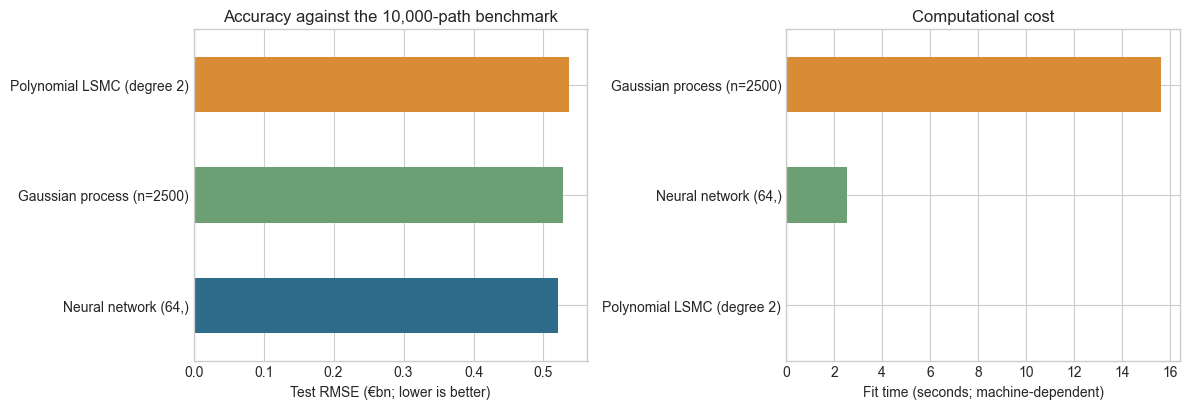

In [4]:
lab2.plot_comparison(experiment)


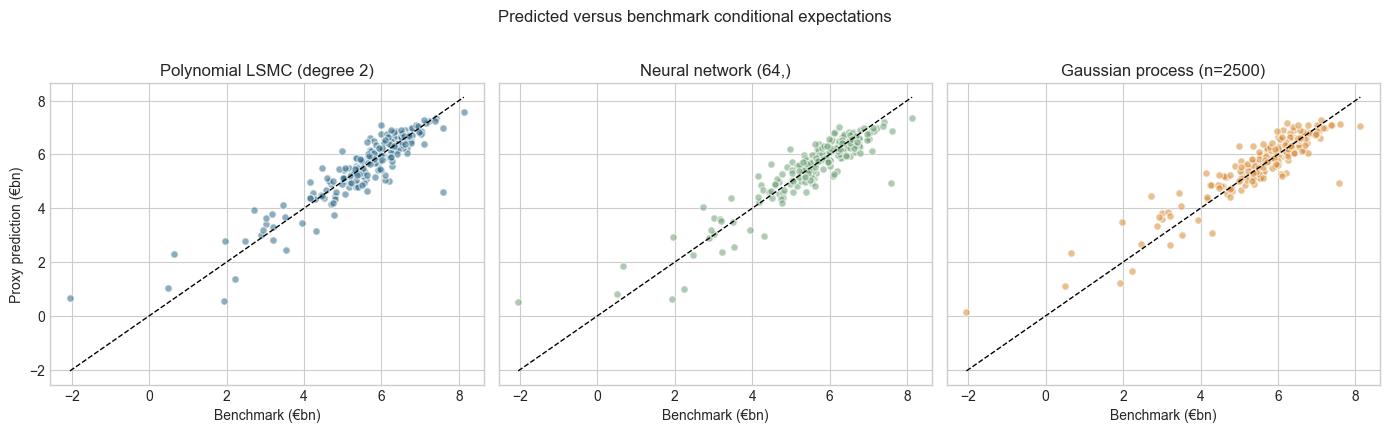

In [5]:
lab2.plot_predictions(experiment)


## Debrief

Discuss:

1. Which model has the smallest benchmark RMSE?
2. How much did the neural-network result change with architecture or activation?
3. How did GP runtime and accuracy change with `GP_TRAINING_SIZE`?
4. Which model would you choose for a production proxy, and what else would you validate first?
